To define the chemical space of the MetAP project, I will do two plots being (1) BublePlot of the metals used, showing how many of them we have, and (2) a bar plot showing the reported vs ours against the medical indication

In [1]:
import pandas as pd

bubleplot = pd.read_csv("bubleplot.csv")

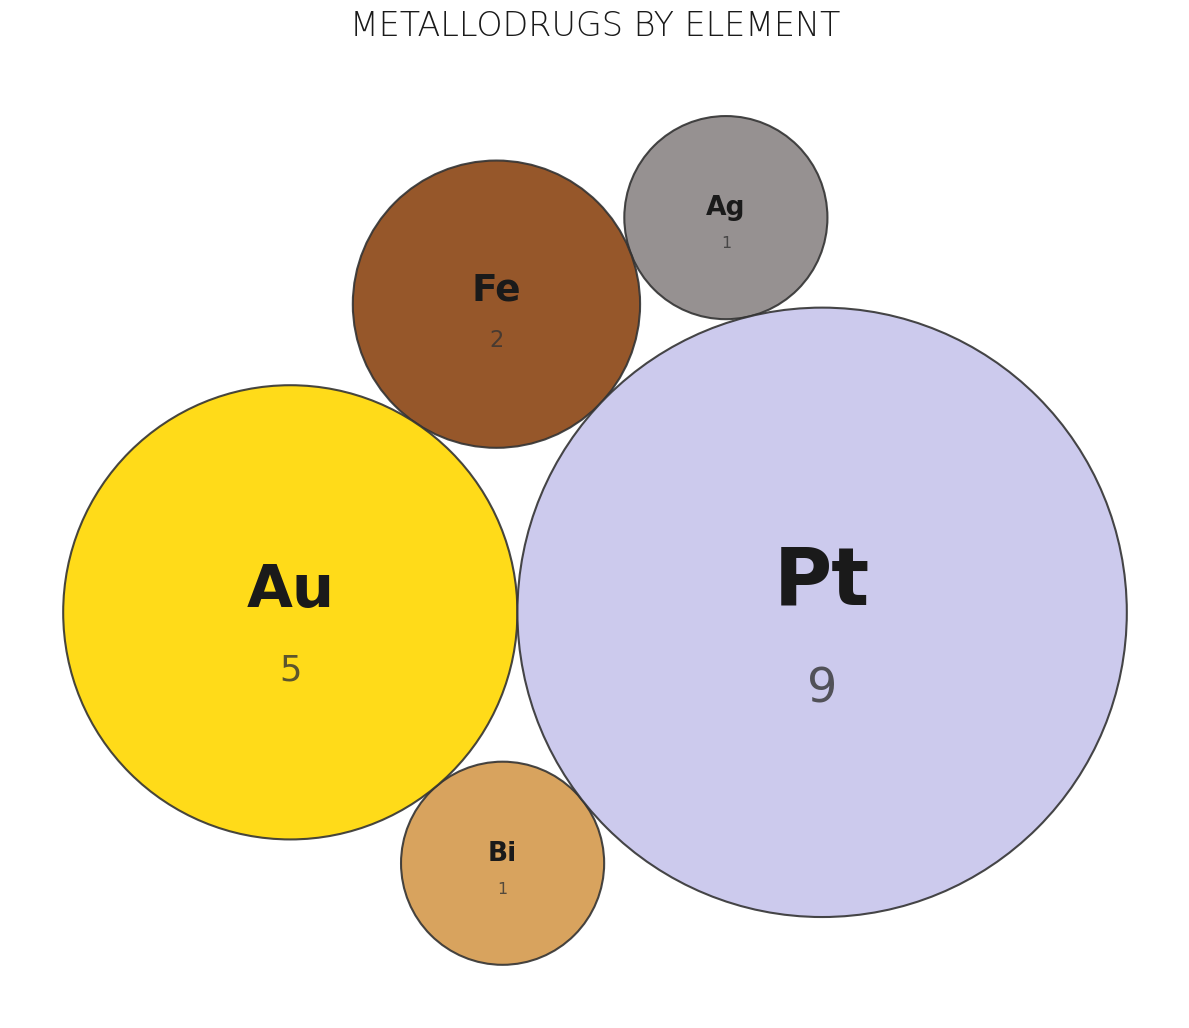

In [2]:
import matplotlib.pyplot as plt
import circlify
import pandas as pd
import matplotlib as mpl

# --- 1. Data Prep ---
# Assuming 'bubleplot' is your original DataFrame
df = bubleplot.sort_values('metallodrugs', ascending=False).reset_index(drop=True)

# We include the ID and the value in the circlify data dictionary
data_dict = [{"id": row['metal'], "datum": row['metallodrugs']} for _, row in df.iterrows()]
circles = circlify.circlify(data_dict, show_enclosure=False, target_enclosure=circlify.Circle(x=0, y=0, r=1))

# --- 2. Setup Plot ---
fig, ax = plt.subplots(figsize=(12, 12), facecolor='#FFFFFF')
ax.set_aspect('equal')

# Calculate boundaries
all_x = [c.x + c.r for c in circles] + [c.x - c.r for c in circles]
all_y = [c.y + c.r for c in circles] + [c.y - c.r for c in circles]
padding = 0.1 
ax.set_xlim(min(all_x) - padding, max(all_x) + padding)
ax.set_ylim(min(all_y) - padding, max(all_y) + padding)
ax.axis('off')

# --- 3. Custom Color Mapping ---
# Define your colors here. If a metal isn't in this list, it uses the 'default'
element_colors = {
    'Pt': "#c7c5eb",
    'Au': '#FFD700',
    'Fe': '#8B4513',
    'Bi': "#D4994C",
    'Ag': "#8B8585",
    'default': '#E2E2E2' # For any metal not specified
}

# --- 4. Plotting Loop ---
for circle in circles:
    x, y, r = circle.x, circle.y, circle.r
    label = circle.ex['id']
    value = circle.ex['datum']
    
    # Selection Logic: Get color from dict, fallback to default if missing
    fill_color = element_colors.get(label, element_colors['default'])
    
    # Draw Bubble
    ax.add_patch(plt.Circle((x, y), r, alpha=0.9, linewidth=1.5, 
                            facecolor=fill_color, edgecolor="#333333"))
    
    # Typography Logic
    if r > 0.03:
        # Metal Name
        ax.text(x, y + (r*0.1), str(label), 
                va='center', ha='center', 
                fontsize=r*100, 
                fontweight='bold',
                color='#1A1A1A')
        
        # Count
        ax.text(x, y - (r*0.25), f"{int(value)}", 
                va='center', ha='center', 
                fontsize=r*60, 
                color='#333333',
                alpha=0.8)

# --- 5. Title ---
ax.set_title("METALLODRUGS BY ELEMENT", 
             fontsize=24, 
             fontweight='light', 
             color='#1A1A1A', 
             pad=20)

plt.tight_layout()
#plt.savefig('metallodrugs_plot.png', dpi=300, bbox_inches='tight', transparent=False)

In [3]:
bargraph = pd.read_csv("bargraph.csv")

In [4]:
display(bargraph)

,indication,MetAP-DB,CT
0,Metallodrug,16,18
1,Radiotherapy metallodrug,5,0
2,Photodynamic therapy,5,0
3,Imaging metallodrug,11,0
4,Radioimaging metallodrug,11,0


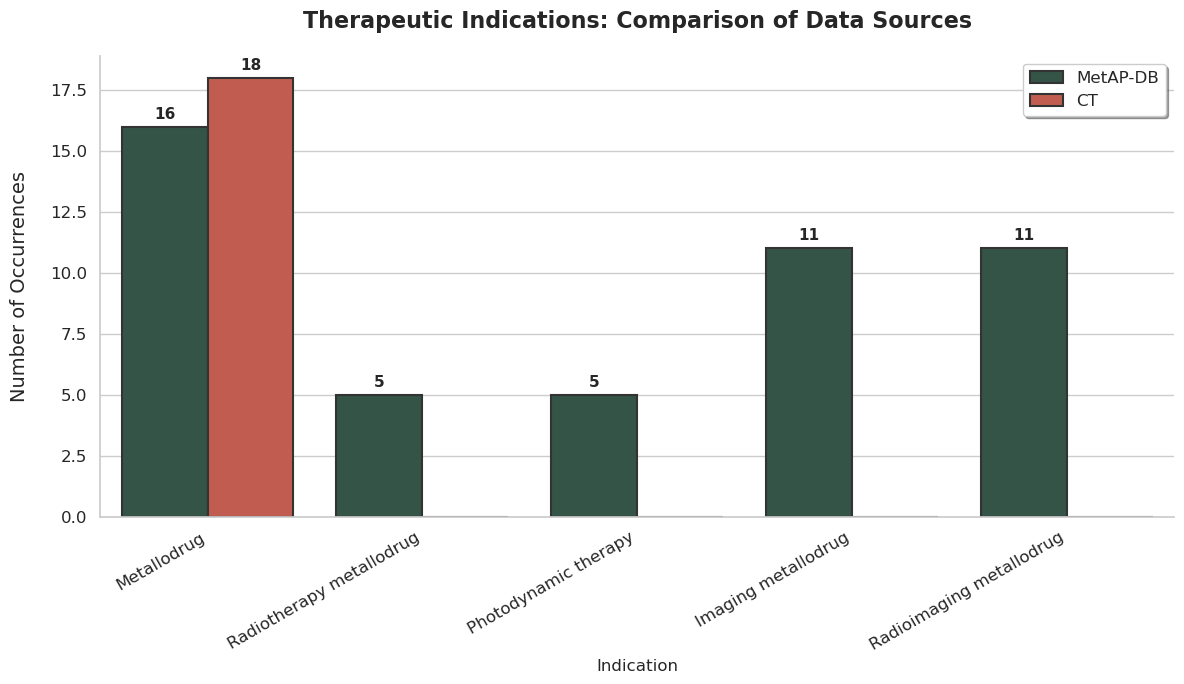

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define the data
data = {
    'Indication': ["Metallodrug", "Radiotherapy metallodrug", "Photodynamic therapy", "Imaging metallodrug", "Radioimaging metallodrug"],
    'MetAP-DB': [16, 5, 5, 11, 11],
    'CT': [18, 0, 0, 0, 0]
}
df = pd.DataFrame(data)

# Reshape for Seaborn plotting (Melt)
df_melted = df.melt(id_vars='Indication', var_name='Source', value_name='Count')

# Apply professional styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.family'] = 'sans-serif'

# Initialize the figure
fig, ax = plt.subplots(figsize=(12, 7))

# Create the bar plot
barplot = sns.barplot(
    data=df_melted, 
    x='Indication', 
    y='Count', 
    hue='Source', 
    edgecolor='0.2', 
    linewidth=1.5,
    palette=['#2D5A47', "#D34F3D"] # Professional blue and orange-salmon colors
)

# Customize titles and labels
ax.set_title('Therapeutic Indications: Comparison of Data Sources', fontsize=16, fontweight='bold', pad=20)
#ax.set_xlabel('Therapeutic/Imaging Indication', fontsize=14, labelpad=15)
ax.set_ylabel('Number of Occurrences', fontsize=14, labelpad=15)

# Rotate x-labels for better readability
plt.xticks(rotation=30, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Add value labels on top of the bars
for p in barplot.patches:
    if p.get_height() > 0:
        barplot.annotate(format(p.get_height(), '.0f'), 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha = 'center', va = 'center', 
                       xytext = (0, 9), 
                       textcoords = 'offset points',
                       fontsize=11, fontweight='bold')

# Refine the legend
plt.legend(fontsize='12', loc='upper right', frameon=True, shadow=True)

sns.despine() # Removes top and right spines
plt.tight_layout()
#plt.savefig('space_descp.png', dpi=300)